In [1]:
readout_freq = 10.3
readout_lo_freq = 10.38 # 10.387
readout_if_freq = readout_lo_freq - readout_freq
JPA_if_freq = readout_freq * 2 - readout_lo_freq * 2

qubit_lo_freq = 7.85
ge_freq = 8.0155+0.005+0.003615-1.7e-6#8.02-0.00233#7.42
anharmonicity = 7.6853-ge_freq+0.013+0.00498+0.00225-1.2e-5
ge_if_freq = ge_freq-qubit_lo_freq

2 * qubit_lo_freq - readout_lo_freq , 2 * ge_freq + anharmonicity - readout_freq

(5.3199999999999985, 5.429631299999999)

In [2]:
2 * ge_freq + anharmonicity - 5.3905

10.339131299999998

In [2]:
readout_freq = 10.306
readout_lo_freq = 10.423  # 10.387
readout_if_freq = readout_lo_freq - readout_freq
JPA_if_freq = readout_freq * 2 - readout_lo_freq * 2

qubit_lo_freq = 7.85
ge_freq = 8.03+0.005106#8.02-0.00233#7.42
anharmonicity = -318e-3-0.00081-0.00056
ge_if_freq = ge_freq-qubit_lo_freq

fogi_lo_freq = 2 * qubit_lo_freq - readout_lo_freq 
fogi_reset_freq = 5.485
fogi_if_freq = -(fogi_reset_freq - fogi_lo_freq) 
                 
fogi_lo_freq, fogi_if_freq, 2 * ge_freq + anharmonicity - readout_freq

(5.276999999999999, -0.20800000000000107, 5.4448419999999995)

## 1/4 ef calibration - DPR1-L-120-44

ef_freq =  

ef_pi_amp = 0.875


T1 = 18.85e-06

T2 = 11.69e-06

T2_star = 7.631e-06

In [1]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
import lmfit

In [2]:
import sklearn
from sklearn.decomposition import PCA

In [3]:
def Rabi(delay, amp, phi0, detun, const):
    return - amp * np.cos(2*np.pi*detun*delay+phi0) + const

amp

In [43]:
header = "D:/K_sunada/result/CDY153/"
ef = "/2024-01-04/2024-01-04T142756_045a72bb-30_ef_pi_amp"
dd_ef = datadict_from_hdf5(header + ef +"/data")

In [44]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

In [45]:
Rabi_ef = dd_ef['s11']['values']
#imag_ge = Rabi_ge.imag
amp_ef = dd_ef['amplitude']['values']

I = (Rabi_ef.real)
Q = (Rabi_ef.imag)

PCAef = PCA_transform(I, Q)

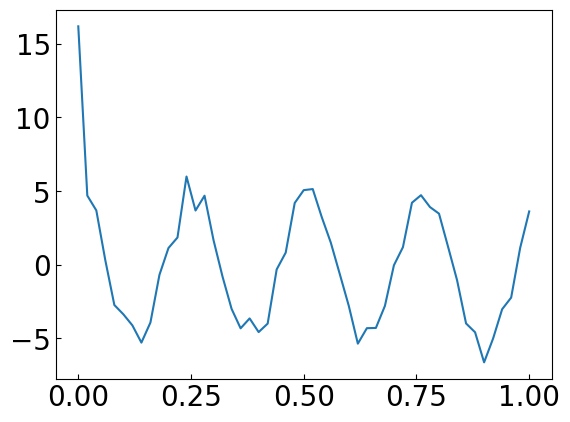

In [46]:
y = PCAef[0]
x = amp_ef

plt.plot(x, y)
plt.show()

In [47]:
par_ini = {
    'amp': 5,
    'phi0':np.pi,
    'detun':1/0.25,
    'const':-1
}

par_min = {
    'amp': 0,
    'phi0':-2*np.pi,
    'detun':-np.inf,
    'const':-np.inf
}

par_max = {
    'amp': np.inf,
    'phi0':2*np.pi,
    'detun':np.inf,
    'const':np.inf,
}

par_vary = {
    'amp': True,
    'phi0':True,
    'detun':True,
    'const':True
}

In [48]:
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

In [49]:
result_ef = model.fit(data = y, params = params, delay = x)
result_ef

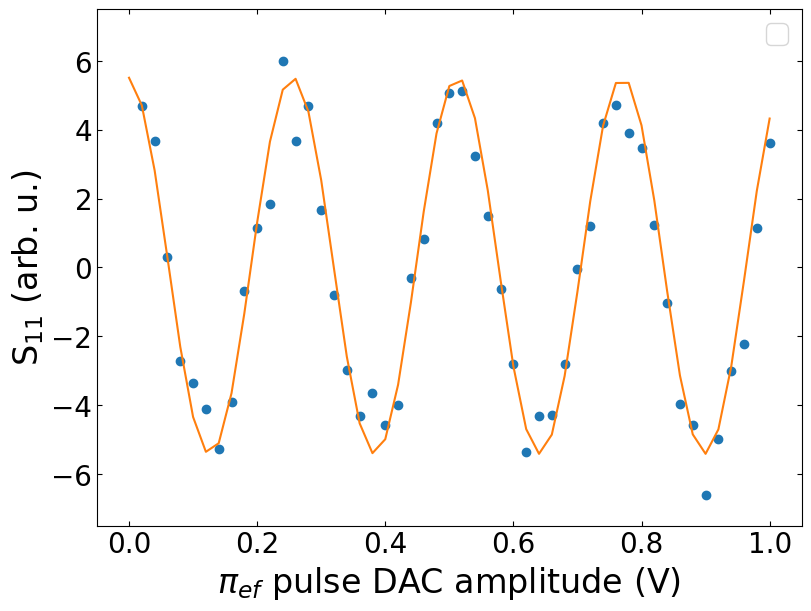

In [50]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
# plt.title("Rabi(amp)")
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_ef.plot_fit(ax = ax)
# plt.plot(amp_ef,result_ef.init_fit)

plt.title("")
plt.legend("")
ax.set_xlabel('$\pi_{ef}$ pulse DAC amplitude (V)', size='large')
ax.set_ylabel('S$_{11}$ (arb. u.)', size='large')
ax.set_ylim(-7.5, 7.5)
# plt.savefig('ef_rabi.png', bbox_inches='tight')
plt.show()

In [51]:
np.pi/(3.88235816*2*np.pi)*5

0.6439385283299057

ramsey

In [21]:
pl = "/2024-01-04/2024-01-04T142227_402b8f37-32_ef_T2r1d"
mi = "/2024-01-04/2024-01-04T142328_648d015d-32_ef_T2r1d"
dd_pl = datadict_from_hdf5(header + pl +"/data")
dd_mi = datadict_from_hdf5(header + mi +"/data")

In [22]:
Rabi_pl = dd_pl['s11']['values']
imag_pl = Rabi_pl.imag
delay_pl = dd_pl['delay']['values']

Rabi_mi = dd_mi['s11']['values']
imag_mi = Rabi_mi.imag
delay_mi = dd_mi['delay']['values']

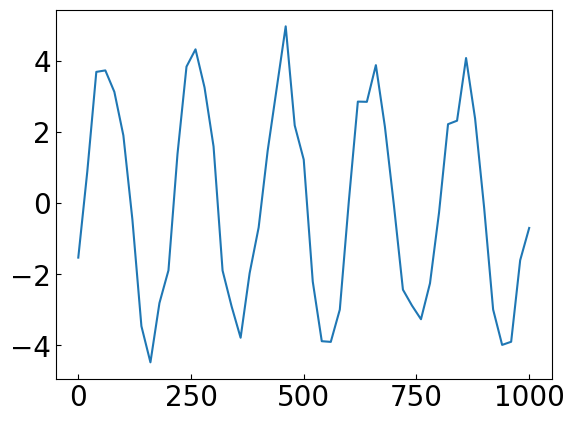

In [23]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2


I_pl = (Rabi_pl.real)
Q_pl = (Rabi_pl.imag)
I_mi = (Rabi_mi.real)
Q_mi = (Rabi_mi.imag)


PCA_pl = PCA_transform(I_pl, Q_pl)
y_pl = PCA_pl[0]
x_pl = delay_pl

PCA_mi = PCA_transform(I_mi, Q_mi)
y_mi = PCA_mi[0]
x_mi = delay_mi



plt.plot(x_pl, y_pl)
plt.show()

In [18]:
par_ini_pl = {
    'amp': 4,
    'phi0':np.pi/2,
    'detun':1/200,
    'const':1
}

par_min_pl = {
    'amp': 0,
    'phi0':-2*np.pi,
    'detun':-np.inf,
    'const':0
}

par_max_pl = {
    'amp': np.inf,
    'phi0':2*np.pi,
    'detun':np.inf,
    'const':np.inf,
}

par_vary_pl = {
    'amp': True,
    'phi0':True,
    'detun':True,
    'const':True
}

In [19]:
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_pl[name],
    min = par_min_pl[name],
    max = par_max_pl[name],
    vary = par_vary_pl[name]
    )
    
result_pl = model.fit(data = y_pl, params = params, delay = x_pl)
result_pl

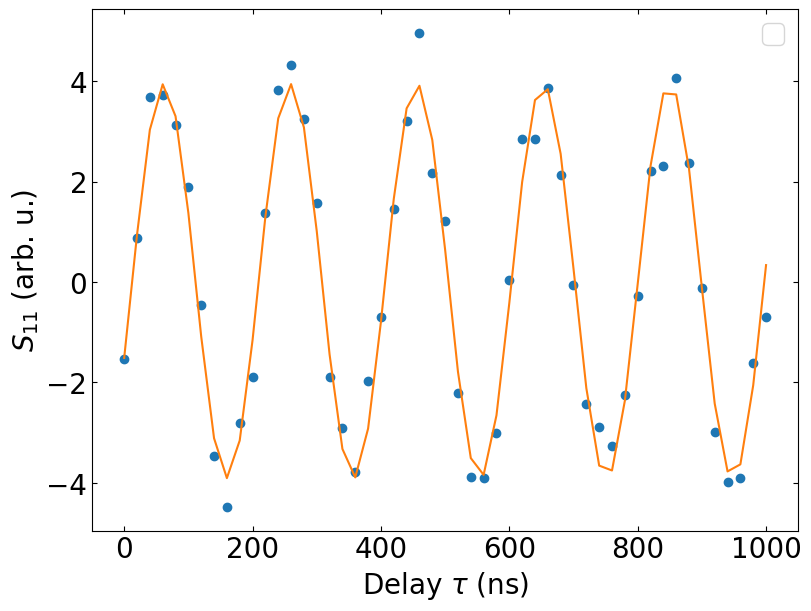

In [20]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)

# plt.title("Rabi(+5MHz)")

# plt.plot(x_pl,result_pl.init_fit)
plt.rcParams["font.size"] = 20

plt.tick_params(top='on',bottom='on',left='on',right='on',)

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_pl.plot_fit(ax = ax)
# plt.plot(x_pl,result_pl.init_fit)

plt.title("")
plt.legend("")
plt.xlabel(r"Delay ${\tau}$ (ns)")
plt.ylabel("$S_{11}$ (arb. u.)")

# plt.savefig('ef_ramsey_exp.png', bbox_inches='tight')
plt.show()

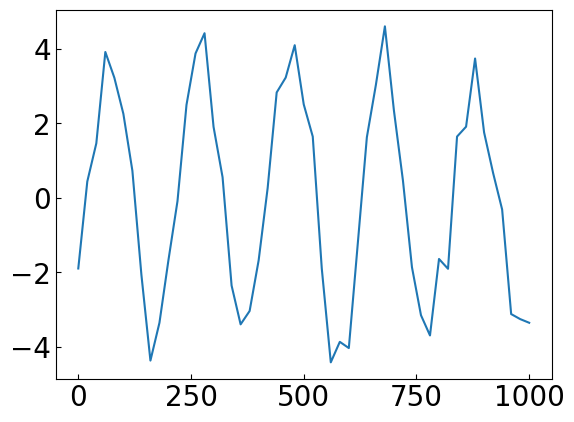

In [24]:
plt.plot(x_mi, y_mi)
plt.show()

In [34]:
par_ini_mi = {
    'amp': 4,
    'phi0':0,
    'detun':1/190,
    'const':-0.3
}

par_min_mi = {
    'amp': 0,
    'phi0':-2*np.pi,
    'detun':-np.inf,
    'const':0
}

par_max_mi = {
    'amp': np.inf,
    'phi0':2*np.pi,
    'detun':np.inf,
    'const':np.inf,
}

par_vary_mi = {
    'amp': True,
    'phi0':True,
    'detun':True,
    'const':True
}

In [35]:
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_mi[name],
    min = par_min_mi[name],
    max = par_max_mi[name],
    vary = par_vary_mi[name]
    )
    
result_mi = model.fit(data = y_mi, params = params, delay = x_mi)
result_mi

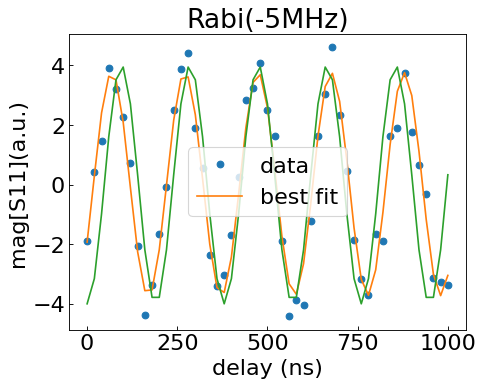

In [36]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(-5MHz)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_mi.plot_fit(ax = ax)
plt.plot(x_mi,result_mi.init_fit)

plt.xlabel("delay (ns)")
plt.ylabel("mag[S11](a.u.)")


plt.show()


In [37]:
detun = ((0.005-0.00507670)+ (0.00493448	-0.005))/2 #GHz
detun

-7.11100000000001e-05

drag

In [72]:
drag = "/2024-01-04/2024-01-04T143253_b518eedb-31_ef_pi_drag" #n=7
dd_drag = datadict_from_hdf5(header + drag +"/data")

drag1 = "/2024-01-04/2024-01-04T143358_dc10bac6-31_ef_pi_drag" #n=11
dd_drag1 = datadict_from_hdf5(header + drag1 +"/data")

drag2 = "/2024-01-04/2024-01-04T143502_022ad839-31_ef_pi_drag" #n=17
dd_drag2 = datadict_from_hdf5(header + drag2 +"/data")

In [73]:
Rabi_drag = dd_drag['s11']['values']
imag_drag = Rabi_drag.imag
drag = dd_drag['beta']['values']
I_drag = (Rabi_drag.real)
Q_drag = (Rabi_drag.imag)

Rabi_drag1 = dd_drag1['s11']['values']
imag_drag1 = Rabi_drag1.imag
drag1 = dd_drag1['beta']['values']
I_drag1 = (Rabi_drag1.real)
Q_drag1 = (Rabi_drag1.imag)

Rabi_drag2 = dd_drag2['s11']['values']
imag_drag2 = Rabi_drag2.imag
drag2 = dd_drag2['beta']['values']
I_drag2 = (Rabi_drag2.real)
Q_drag2 = (Rabi_drag2.imag)

In [74]:
def PCA_transform1(Re_c_amp, Im_c_amp, Re_c_drag, Im_c_drag):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c_amp]).T, np.array([Im_c_amp]).T], axis = 1)
    c1_data = np.concatenate([np.array([Re_c_drag]).T, np.array([Im_c_drag]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    
    c1_pca = pca.transform(c1_data)
    c1_PCA1 = c1_pca.T[0]
    c1_PCA2 = c1_pca.T[1]
    return c_PCA1, c_PCA2, c1_PCA1, c1_PCA2,

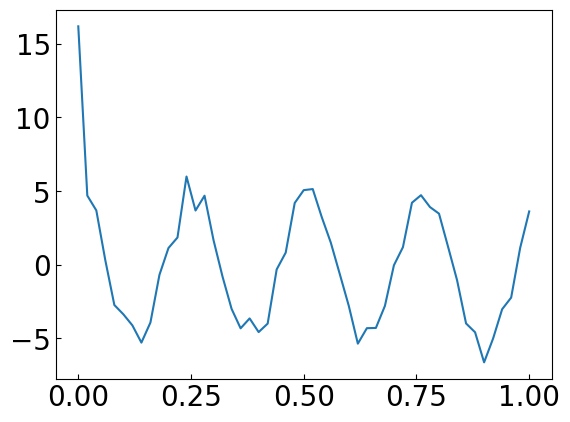

In [75]:
PCA_drag = PCA_transform1(I, Q, I_drag, Q_drag)
y = PCA_drag[0]
x = amp_ef
y0 = PCA_drag[2]
x0 = drag

PCA_drag1 = PCA_transform1(I, Q, I_drag1, Q_drag1)
y1 = PCA_drag1[2]
x1 = drag1

PCA_drag2 = PCA_transform1(I, Q, I_drag2, Q_drag2)
y2 = PCA_drag2[2]
x2 = drag2


plt.plot(x, y)
plt.show()

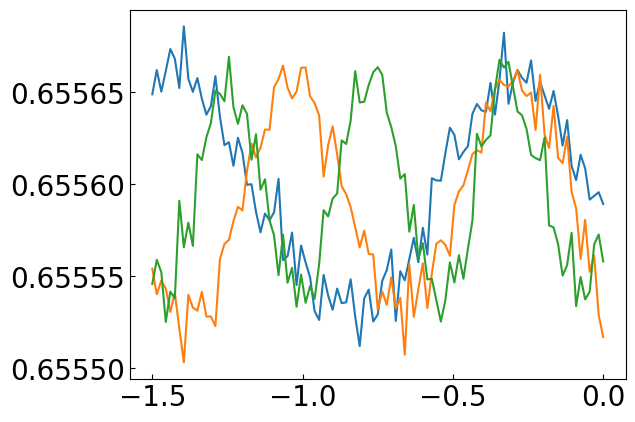

In [76]:
plt.plot(x0, y0)
plt.plot(x1, y1)
plt.plot(x2, y2)
plt.show()

In [91]:
par_ini= {
    'amp': 0.00005,
    'phi0':0,
    'detun':1/0.5,
    'const':0.6556
}

par_min = {
    'amp': 0,
    'phi0':-2*np.pi,
    'detun':0,
    'const':-np.inf
}

par_max = {
    'amp': np.inf,
    'phi0':2*np.pi,
    'detun':np.inf,
    'const':np.inf,
}

par_vary = {
    'amp': True,
    'phi0':True,
    'detun':True,
    'const':True
}

In [92]:
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
    
result0 = model.fit(data = y0, params = params, delay = x0)
result1 = model.fit(data = y1, params = params, delay = x1)
result2 = model.fit(data = y2, params = params, delay = x2)

In [79]:
result0

In [81]:
res0 = (np.pi-4.76783477)/(2*np.pi*0.88984747)
res0

-0.29086386174802514

In [82]:
result1

In [84]:
res1 = (np.pi-5.66620247)/(2*np.pi*1.36774571)
res1

-0.29377107800250885

In [93]:
result2

In [97]:
res2 = (-np.pi-1.05363620)/(2*np.pi*2.14809179)
res2

-0.3108300178599727

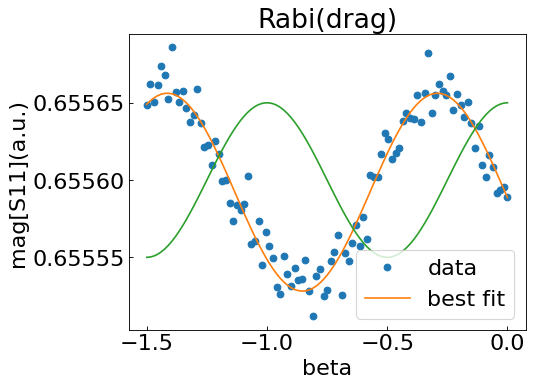

In [80]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(drag)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result0.plot_fit(ax = ax)
plt.plot(x0,result0.init_fit)

plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")

plt.show()

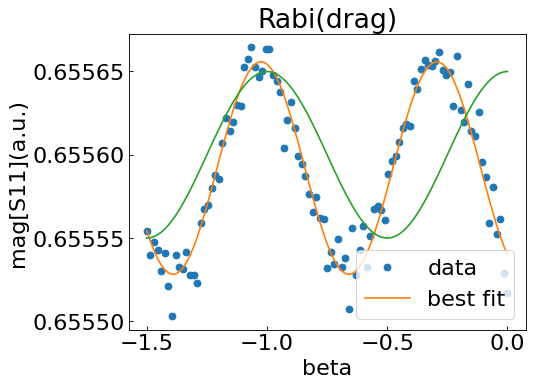

In [83]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(drag)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result1.plot_fit(ax = ax)
plt.plot(x1,result1.init_fit)


plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")

plt.show()

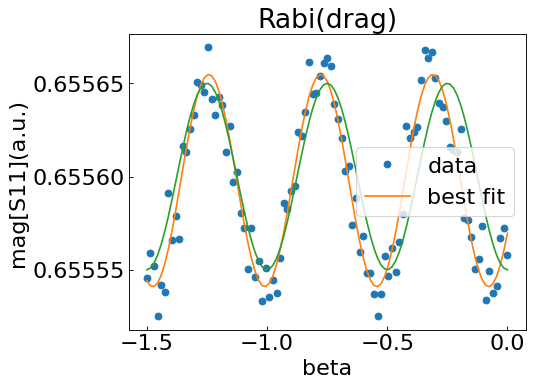

In [94]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(drag)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result2.plot_fit(ax = ax)

plt.plot(x2,result2.init_fit)


plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")

plt.show()


In [98]:
beta = (res0 + res1 + res2)/3
beta

-0.2984883192035022

half drag

In [116]:
drag = "/2024-01-04/2024-01-04T144233_0f203953-31_ef_pi_drag" #n=13
dd_drag = datadict_from_hdf5(header + drag +"/data")

drag1 = "/2024-01-04/2024-01-04T144340_36c66f49-31_ef_pi_drag" #n=17
dd_drag1 = datadict_from_hdf5(header + drag1 +"/data")

drag2 = "/2024-01-04/2024-01-04T144452_61cc4722-31_ef_pi_drag" #n=23
dd_drag2 = datadict_from_hdf5(header + drag2 +"/data")

In [117]:
Rabi_drag = dd_drag['s11']['values']
imag_drag = Rabi_drag.imag
drag = dd_drag['beta']['values']
I_drag = (Rabi_drag.real)
Q_drag = (Rabi_drag.imag)

Rabi_drag1 = dd_drag1['s11']['values']
imag_drag1 = Rabi_drag1.imag
drag1 = dd_drag1['beta']['values']
I_drag1 = (Rabi_drag1.real)
Q_drag1 = (Rabi_drag1.imag)

Rabi_drag2 = dd_drag2['s11']['values']
imag_drag2 = Rabi_drag2.imag
drag2 = dd_drag2['beta']['values']
I_drag2 = (Rabi_drag2.real)
Q_drag2 = (Rabi_drag2.imag)

In [118]:
def PCA_transform1(Re_c_amp, Im_c_amp, Re_c_drag, Im_c_drag):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c_amp]).T, np.array([Im_c_amp]).T], axis = 1)
    c1_data = np.concatenate([np.array([Re_c_drag]).T, np.array([Im_c_drag]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    
    c1_pca = pca.transform(c1_data)
    c1_PCA1 = c1_pca.T[0]
    c1_PCA2 = c1_pca.T[1]
    return c_PCA1, c_PCA2, c1_PCA1, c1_PCA2,

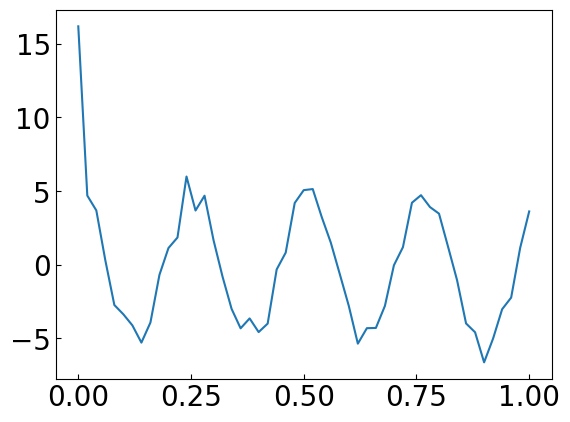

In [119]:
PCA_drag = PCA_transform1(I, Q, I_drag, Q_drag)
y = PCA_drag[0]
x = amp_ef
y0 = PCA_drag[2]
x0 = drag

PCA_drag1 = PCA_transform1(I, Q, I_drag1, Q_drag1)
y1 = PCA_drag1[2]
x1 = drag1

PCA_drag2 = PCA_transform1(I, Q, I_drag2, Q_drag2)
y2 = PCA_drag2[2]
x2 = drag2


plt.plot(x, y)
plt.show()

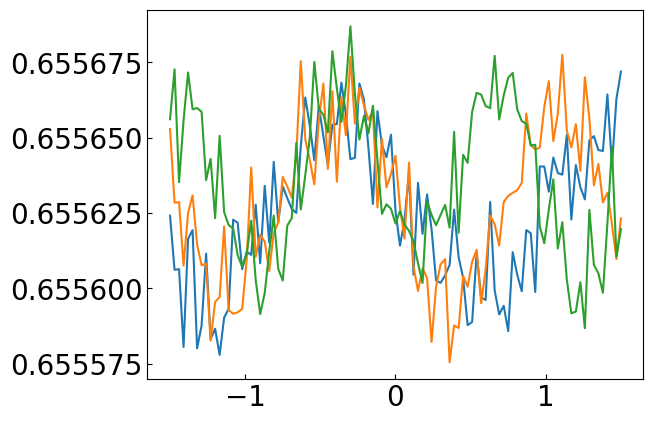

In [120]:
plt.plot(x0, y0)
plt.plot(x1, y1)
plt.plot(x2, y2)
plt.show()

In [121]:
par_ini= {
    'amp': 4e-5,
    'phi0':-np.pi/2,
    'detun':1/1.4,
    'const':0.65562
}

par_min = {
    'amp': 0,
    'phi0':-2*np.pi,
    'detun':-np.inf,
    'const':-np.pi
}

par_max = {
    'amp': np.inf,
    'phi0':2*np.pi,
    'detun':np.inf,
    'const':np.inf,
}

par_vary = {
    'amp': True,
    'phi0':True,
    'detun':True,
    'const':True
}

In [122]:
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
    
result0 = model.fit(data = y0, params = params, delay = x0)
result1 = model.fit(data = y1, params = params, delay = x1)
result2 = model.fit(data = y2, params = params, delay = x2)

In [123]:
result0

In [126]:
res0 = (-np.pi+1.93582474)/(2*np.pi*0.54774261)
res0

-0.35035419951976515

In [127]:
result1

In [129]:
res1 = (-np.pi+1.55318361)/(2*np.pi*0.68937582)
res1

-0.3667131100408852

In [130]:
result2

In [133]:
res2 = (-np.pi+0.93756370)/(2*np.pi*0.92994187)
res2

-0.37720863421438716

In [134]:
(res0+res1+res2)/3

-0.3647586479250125

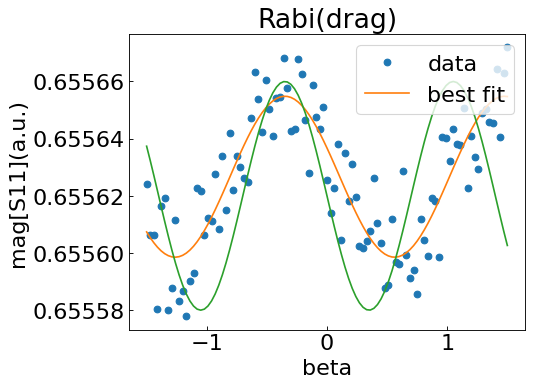

In [124]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(drag)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result0.plot_fit(ax = ax)
plt.plot(x0,result0.init_fit)


plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")

plt.show()

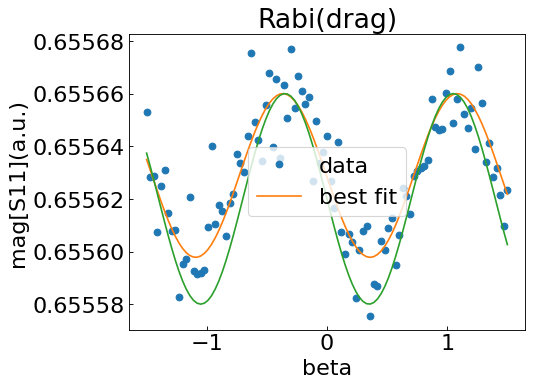

In [128]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(drag)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result1.plot_fit(ax = ax)
plt.plot(x1,result1.init_fit)


plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")

plt.show()

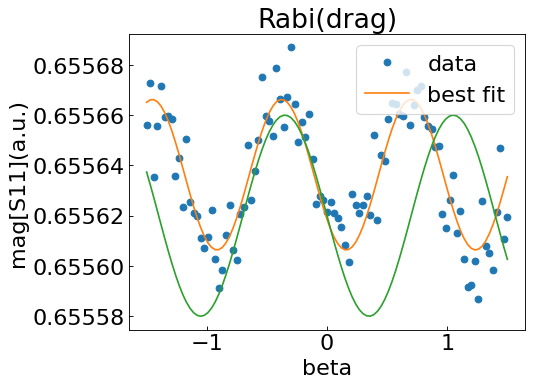

In [131]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(drag)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result2.plot_fit(ax = ax)

plt.plot(x2,result2.init_fit)


plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")

plt.show()


T1

In [139]:
def Dephase(delay, amp, gamma, const):
    return amp*np.exp(-gamma*delay) + const

t1 ="/2024-01-04/2024-01-04T144904_f7d56b89-33_ef_T1"

dd_t1 = datadict_from_hdf5(header + t1 +"/data")

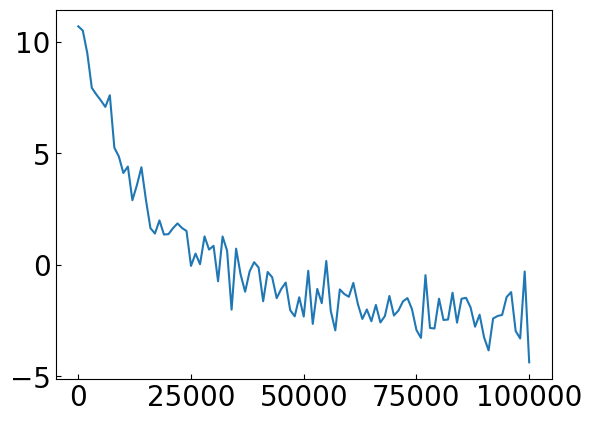

In [140]:
s11_t1 = dd_t1['s11']['values']
imag_t1 = s11_t1.imag
delay_t1 = dd_t1['delay']['values']

I_t1 = (s11_t1.real)
Q_t1 = (s11_t1.imag)

PCA_t1 = PCA_transform(I_t1, Q_t1)

y_t1 = PCA_t1[0]
x_t1 = delay_t1

plt.plot(x_t1, y_t1)
plt.show()

In [141]:
par_ini_t1 = {
    'gamma': 1/20000,
    'amp':20,
    'const':-5
}

par_min_t1 = {
    'gamma': 0,
    'amp':0,
    'const':-np.inf
}

par_max_t1 = {
    'gamma': np.inf,
    'amp':np.inf,
    'const':np.inf,
}

par_vary_t1 = {
    'gamma': True,
    'amp':True,
    'const':True
}

In [142]:
model = lmfit.Model(Dephase)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_t1[name],
    min = par_min_t1[name],
    max = par_max_t1[name],
    vary = par_vary_t1[name]
    )
result_t1 = model.fit(data = y_t1, params = params, delay = x_t1)
result_t1

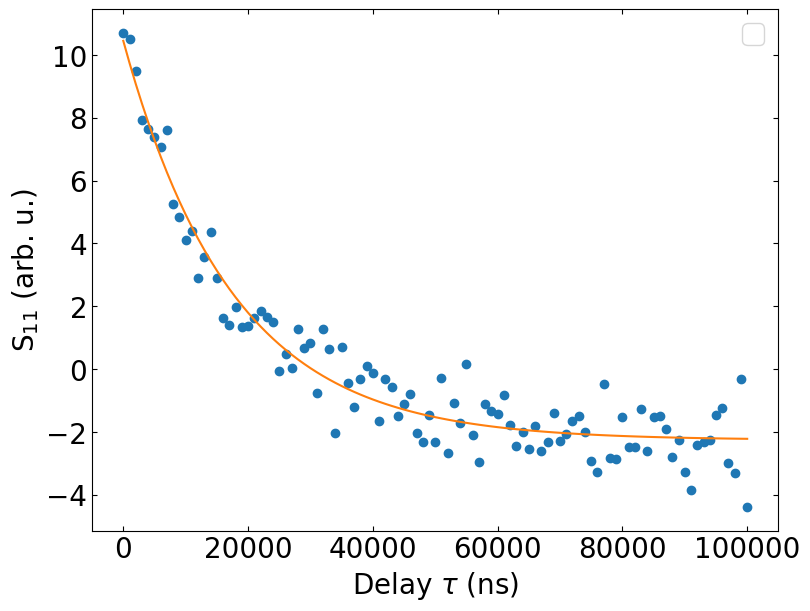

In [143]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20

plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_t1.plot_fit(ax = ax)
# plt.plot(delay_t1,result_t1.init_fit)

plt.title("")
plt.legend("")
ax.set_xlabel(r'Delay $\tau$ (ns)')#, size='large')
ax.set_ylabel('S$_{11}$ (arb. u.)')
# plt.savefig('ef_T1.png', bbox_inches='tight')

plt.show()

In [144]:
T1 = (1/5.7110e-05)*1e-9	
T1

1.7510068289266328e-05

T2

In [66]:
t2e = "/2023-12-26/2023-12-26T174420_f652f8c8-34_ef_T2e"
dd_t2e = datadict_from_hdf5(header + t2e +"/data")

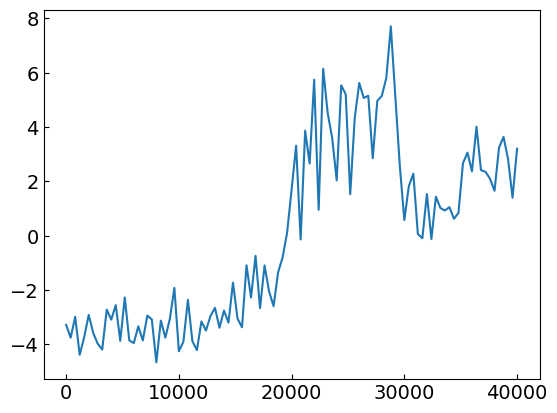

In [67]:
s11_t2e = dd_t2e['s11']['values']
imag_t2e = s11_t2e.imag
delay_t2e = dd_t2e['delay']['values']

I_t2e = (s11_t2e.real)
Q_t2e = (s11_t2e.imag)

PCA_t2e = PCA_transform(I_t2e, Q_t2e)

y_t2e = PCA_t2e[0]
x_t2e = delay_t2e

plt.plot(x_t2e, y_t2e)
plt.show()

In [68]:
par_ini_t2e = {
    'gamma': 1/2000,
    'amp':8,
    'const':0
}

par_min_t2e = {
    'gamma': 0,
    'amp':0,
    'const':-np.inf
}

par_max_t2e = {
    'gamma': np.inf,
    'amp':np.inf,
    'const':np.inf,
}

par_vary_t2e = {
    'gamma': True,
    'amp':True,
    'const':True
}

In [69]:
model = lmfit.Model(Dephase)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_t2e[name],
    min = par_min_t2e[name],
    max = par_max_t2e[name],
    vary = par_vary_t2e[name]
    )
result_t2e = model.fit(data = y_t2e, params = params, delay = x_t2e)
result_t2e

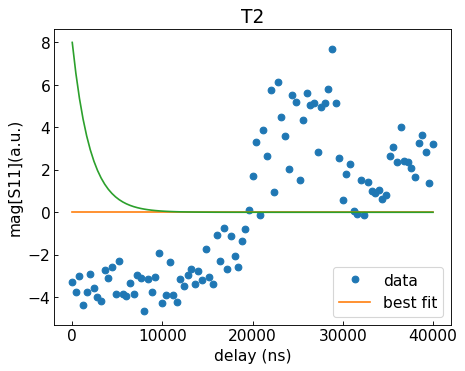

In [70]:
fig, ax = plt.subplots(dpi=80)

plt.title("T2")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_t2e.plot_fit(ax = ax)
plt.plot(delay_t2e,result_t2e.init_fit)

plt.xlabel("delay (ns)")
plt.ylabel("mag[S11](a.u.)")

plt.show()

In [71]:
T2 = (1/8.5514e-05)*1e-9	
T2

1.1693991627101997e-05

T2 star

In [72]:
def Damping(delay, amp, gamma, omega, phi0, const):
    return const + amp * np.exp(- gamma*delay)*np.cos(omega*delay + phi0)

In [73]:
t2 = "/2023-12-26/2023-12-26T173450_a23294f7-32_ef_T2r1d"
dd_t2 = datadict_from_hdf5(header + t2 +"/data")

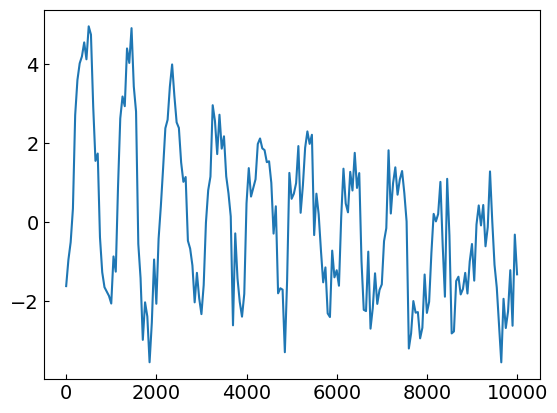

In [74]:
s11_t2 = dd_t2['s11']['values']
imag_t2 = s11_t2.imag
delay_t2 = dd_t2['delay']['values']

I_t2 = (s11_t2.real)
Q_t2 = (s11_t2.imag)

PCA_t2 = PCA_transform(I_t2, Q_t2)

y_t2 = PCA_t2[0]
x_t2 = delay_t2

plt.plot(x_t2, y_t2)
plt.show()

In [75]:
par_ini_t2 = {
    'amp':3,
    'gamma': 1/6000,
    'omega':2*np.pi/1000,
    'phi0':0,
    'const':-0.5
}

par_min_t2 = {
    'amp':-np.inf,
    'gamma': 0,
    'omega':-2*np.pi,
    'phi0':-2*np.pi,
    'const':-np.inf
}

par_max_t2 = {
    'amp':np.inf,
    'gamma': np.inf,
    'omega':2*np.pi,
    'phi0':2*np.pi,
    'const':np.inf
}

par_vary_t2 = {
    'amp':True,
    'gamma': True,
    'omega':True,
    'phi0':True,
    'const':True
}

In [76]:
model = lmfit.Model(Damping)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_t2[name],
    min = par_min_t2[name],
    max = par_max_t2[name],
    vary = par_vary_t2[name]
    )
result_t2 = model.fit(data = y_t2, params = params, delay = x_t2)
result_t2

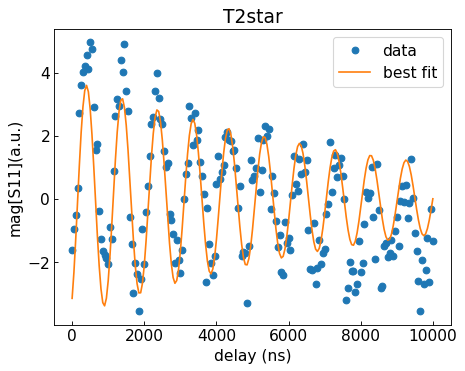

In [77]:
fig, ax = plt.subplots(dpi=80)

plt.title("T2star")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_t2.plot_fit(ax = ax)
# plt.plot(delay_t2,result_t2.init_fit)

plt.xlabel("delay (ns)")
plt.ylabel("mag[S11](a.u.)")

plt.show()

In [78]:
T2_star = (1/1.2078e-04)*1e-9	
T2_star

8.27951647623779e-06